In [1]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt

# assume the notebook is launched from the project root; make sure it is importable
sys.path.insert(0, os.getcwd())

from func.model_1plaq import Villain_dist_norm_visualize
from fit_v_dist_batch import (
    list_train_candidates,
    pick_candidate,
    load_vortex_arrays,
    VORTEX_TAGS,
)

In [2]:
# --- case to visualize: edit to match a generated + fitted case ---
N = 2
L = 4
beta, beta1, alpha, alpha1 = 1.0, 0.0, 0.5, 0.0
boundary_BC = "OBC"
boundary_pad = 5
mod = 0

# entry_mod follows fit_v_dist_batch's path convention (beta1=0 "Original" -> mod 0)
entry_mod = 0 if abs(beta1) < 1e-10 else mod

data_folder = f"data/data_{boundary_BC}_pad{boundary_pad}_mod{entry_mod}/N{N}_L{L}"
json_path = (
    f"results/v_dist_fit_{boundary_BC}_pad{boundary_pad}_mod{entry_mod}/N{N}_L{L}/"
    f"v_dist_fit_beta{beta:.3f}_beta1_{beta1:.3f}_alpha{alpha:.3f}_alpha1_{alpha1:.3f}_"
    f"N{N}_L{L}_{boundary_BC}_pad{boundary_pad}_mod{entry_mod}.json"
)

In [3]:
# --- load the data (highest-statistics file) and the per-vortex fit results ---
# NOTE: match on entry_mod (== file_mod used in the data filename), consistent
# with fit_v_dist_batch.main(): beta1=0 "Original" entries are written under mod 0.
candidates = list_train_candidates(data_folder, N, L, beta, beta1, alpha, alpha1, entry_mod)
selected = pick_candidate(candidates)
if selected is None:
    raise FileNotFoundError(f"No train data in {data_folder} for this case.")
print("data file :", selected["file_name"])

arrays = load_vortex_arrays(selected["file_path"])

with open(json_path) as fh:
    result = json.load(fh)

# Build a per-tag view. For each vortex type:
#   X[:, 0] = integer vortex bin center, X[:, 1] = boundary flux da (da_U for U/s,
#   da_z for z); freq = histogram density. f = vortex + da/(2*pi) is the effective
#   continuous winding plotted on the x axis.
per_tag = {}
for tag in VORTEX_TAGS:
    X = arrays[f"X_{tag}"]
    freq = arrays[f"freq_{tag}"]
    f = X[:, 0] + X[:, 1] / (2 * np.pi)
    fit = result["villain_fit"][tag]
    ok = bool(fit.get("success", False)) and fit.get("alpha_fit") is not None
    per_tag[tag] = {
        "f": f,
        "freq": freq,
        "alpha_fit": fit.get("alpha_fit"),
        "mse": fit.get("villain_mse_train"),
        "ok": ok,
        "error": fit.get("error"),
    }
    if ok:
        print(f"  {tag}: alpha_fit={per_tag[tag]['alpha_fit']:.6g}  "
              f"mse={per_tag[tag]['mse']:.3e}  "
              f"f range=[{f.min():.3f}, {f.max():.3f}]  n={f.size}")
    else:
        print(f"  {tag}: FIT FAILED ({per_tag[tag]['error']}) -> data only, "
              f"f range=[{f.min():.3f}, {f.max():.3f}]  n={f.size}")

data file : data_beta1.000_beta1_0.000_alpha0.500_alpha1_0.000_num2000_zpad1_N2_L4_OBC_pad5_mod0.npz
  U: alpha_fit=0.135551  mse=2.850e-02  f range=[-3.797, 3.879]  n=11111
  z: alpha_fit=0.215774  mse=5.722e-03  f range=[-3.982, 3.743]  n=10665
  s: alpha_fit=0.118974  mse=2.072e-02  f range=[-4.174, 4.376]  n=12333


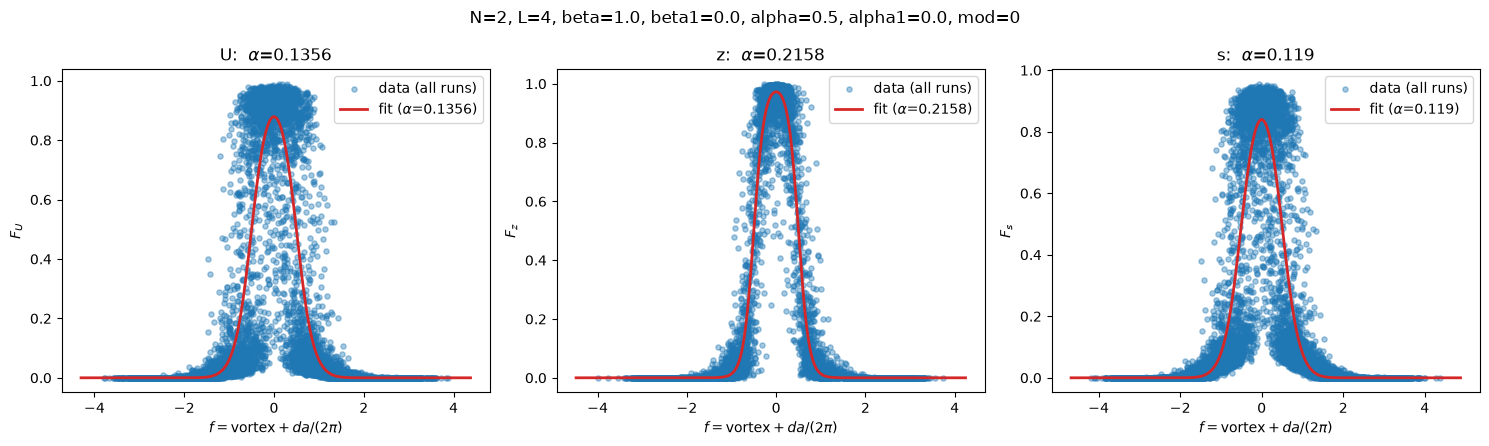

In [4]:
# --- plot: one panel per vortex type (U, z, s). If a tag's fit failed, only the
#     data scatter is drawn for that panel (no fit curve). ---
n_panels = len(VORTEX_TAGS)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.5))
if n_panels == 1:
    axes = [axes]

for ax, tag in zip(axes, VORTEX_TAGS):
    d = per_tag[tag]
    ax.scatter(d["f"], d["freq"], s=14, alpha=0.4, color="C0",
               label="data (all runs)", zorder=2)
    if d["ok"]:
        f_grid = np.linspace(d["f"].min() - 0.5, d["f"].max() + 0.5, 2000)
        ax.plot(f_grid, Villain_dist_norm_visualize(f_grid, d["alpha_fit"]),
                color="C3", lw=2, zorder=3,
                label=(r"fit ($\alpha$=" + f"{d['alpha_fit']:.4g})"))
        ax.set_title(rf"{tag}:  $\alpha$={d['alpha_fit']:.4g}")
    else:
        ax.set_title(rf"{tag}: fit failed (data only)")
    ax.set_xlabel(r"$f = \mathrm{vortex} + da / (2\pi)$")
    ax.set_ylabel(rf"$F_{{{tag}}}$")
    ax.legend()
    # ax.set_yscale("log")   # uncomment to inspect the Gaussian tails / zero-padded bins

fig.suptitle(
    f"N={N}, L={L}, beta={beta}, beta1={beta1}, "
    f"alpha={alpha}, alpha1={alpha1}, mod={entry_mod}"
)
fig.tight_layout()
plt.show()